# 听声辨情：基于 OpenVINO + Qwen3-ASR 的端侧客服语音智能质检系统

> Intel AI PC 端侧推理 | Qwen3-ASR + OpenVINO | 转录 · 情绪标记 · 质检报告

## 应用场景

客服中心每天产生大量通话录音，人工质检效率低、覆盖率不足 5%。**VoiceQC 的解法**：

```
客服录音
      ↓  Qwen3-ASR（OpenVINO 加速）
转录文本
      ↓  情绪分析器（本项目核心创新）
逐句情绪标注 😠愤怒 / 😰焦虑 / 😊满意 / 😐中性
      ↓
质检报告：问题分类 + 解决状态 + 高风险语句 + 建议
```

**全程本地运行，通话内容不离开设备，保护客户隐私。**

## 目录
0. 环境与配置
1. 选择推理设备
2. 加载 Qwen3-ASR 模型
3. 语音转录测试
4. 情绪分析器演示（核心创新）
5. 完整质检 Pipeline
6. 批量处理对比
7. Gradio 一键演示

## 0 环境与配置

In [29]:
import warnings, sys, time
from pathlib import Path

warnings.filterwarnings('ignore')
WORK_DIR = Path.cwd().resolve()
print(f'Work dir : {WORK_DIR}')
print(f'Python   : {sys.version.split()[0]}')

import openvino as ov
core = ov.Core()
print(f'OpenVINO : {ov.__version__}')
print(f'Devices  : {core.available_devices}')

Work dir : D:\zicheng_lee\modelscope-workshop\voiceqc
Python   : 3.14.2
OpenVINO : 2026.1.0-21367-63e31528c62-releases/2026/1
Devices  : ['CPU', 'GPU', 'NPU']


## 1 选择推理设备

In [30]:
# 因 VS Code ipywidgets 渲染问题，直接确定设备
class _Device:
    value = 'CPU'

device = _Device()
print(f'Device: {device.value}')

Device: CPU


## 2 加载模型

Qwen3-ASR-0.6B 支持 52+ 种语言，模型大小约 1.2 GB。

如果已在 `voicesketch/` 目录下载过，会直接复用，无需重新下载。

In [31]:
from pathlib import Path
from modelscope import snapshot_download

# 模型固定下载到仓库根目录
MODEL_DIR = Path(r'D:\zicheng_lee\modelscope-workshop\Qwen3-ASR-0.6B-fp16-ov')

if MODEL_DIR.exists():
    print(f'Found model: {MODEL_DIR}')
else:
    print('Downloading Qwen3-ASR (~1.2 GB) ...')
    snapshot_download('snake7gun/Qwen3-ASR-0.6B-fp16-ov', local_dir=str(MODEL_DIR))
    print('Done.')

asr_model_dir = MODEL_DIR

Found model: D:\zicheng_lee\modelscope-workshop\Qwen3-ASR-0.6B-fp16-ov


In [32]:
import sys, time
from pathlib import Path

# 绝对路径，不依赖任何上方 cell
asr_model_dir = Path(r'D:\zicheng_lee\modelscope-workshop\Qwen3-ASR-0.6B-fp16-ov')
lab2_dir      = Path(r'D:\zicheng_lee\modelscope-workshop\lab2-speech-recognition')

sys.path.insert(0, str(lab2_dir))
from qwen_3_asr_helper import OVQwen3ASRModel

print(f'Model : {asr_model_dir}')
print(f'Device: CPU')
t0 = time.time()
asr_model = OVQwen3ASRModel.from_pretrained(model_dir=asr_model_dir, device='CPU')
print(f'ASR model ready ({time.time()-t0:.1f}s)')
print(f'Langs : {asr_model.get_supported_languages()[:6]} ...')

Model : D:\zicheng_lee\modelscope-workshop\Qwen3-ASR-0.6B-fp16-ov
Device: CPU
Loading OV models from D:\zicheng_lee\modelscope-workshop\Qwen3-ASR-0.6B-fp16-ov on CPU…
All models loaded ✅
Processor loaded ✅
OVQwen3ASRModel ready ✅
ASR model ready (2.4s)
Langs : ['Chinese', 'English', 'Cantonese', 'Arabic', 'German', 'French'] ...


## 3 语音转录测试

支持上传 .wav/.mp3 文件，或使用模拟对话文本跳过此步直接到第 4 节。

In [ ]:
import time
from pathlib import Path

# 测试音频：客服投诉场景（我们日常生活中的快递行业中文客服场景）
AUDIO_PATH = Path(r'D:\zicheng_lee\modelscope-workshop\voiceqc\assets\sample_call.wav')

if AUDIO_PATH.exists():
    t0 = time.time()
    results = asr_model.transcribe(audio=str(AUDIO_PATH), language='Chinese')
    transcript_from_audio = results[0].text
    print(f'ASR done ({time.time()-t0:.2f}s)')
    print(f'Transcript: {transcript_from_audio}')
else:
    print('No audio file found. Using example transcript in section 4.')
    transcript_from_audio = None

ASR done (18.79s)
Transcript: 我的快递等了整整一周还没到，这什么物流？非常抱歉，我立刻为您查询。你们每次都这么说，根本没用。已为您提交加急处理，二十四小时内专员联系您。


## 4 情绪分析器演示（核心创新）

`sentiment_analyzer.py` 是本项目的核心创新点：

- **逐句情绪分类**：愤怒 / 焦虑 / 满意 / 轻微不满 / 中性
- **关键词正则匹配**：投诉、退款、意外、感谢等 100+ 词条
- **问题分类检测**：物流 / 质量 / 账号 / 支付 / 商品描述 7 类
- **解决状态识别**：检测本次通话是否完成问题解决
- **说话人区分（客服/客户）**：启发式标识
- **综合满意度评分**：-1.0（极差）~ +1.0（极好）

In [34]:
from sentiment_analyzer import analyze, analyze_sentence

# 单句情绪测试
test_sentences = [
    '我的快递等了整整一周还没到，这什么物流！',
    '这次服务怎么这么差，我要投诉你们！',
    '非常感谢，问题已经很快解决了，满意。',
    '订单号是多少，我帮您查询一下。',
    '我很急，今天必须到，还要多久？',
]

print(f'{"="*60}')
print(f'  单句情绪分析测试')
print(f'{"="*60}')
for sent in test_sentences:
    r = analyze_sentence(sent)
    from sentiment_analyzer import EMOTION_EMOJI
    label = EMOTION_EMOJI[r.emotion]
    kw    = ', '.join(r.keywords_hit[:3]) if r.keywords_hit else '无'
    print(f'{label:15s}  score={r.score:+.2f}  | {sent[:28]}')
    print(f'               命中关键词: {kw}')

  单句情绪分析测试
😐 中性             score=+0.00  | 我的快递等了整整一周还没到，这什么物流！
               命中关键词: 无
😠 愤怒             score=-1.00  | 这次服务怎么这么差，我要投诉你们！
               命中关键词: 投诉, 投诉你们
😊 满意             score=+1.00  | 非常感谢，问题已经很快解决了，满意。
               命中关键词: 感谢, 非常感谢, 满意
😐 中性             score=+0.00  | 订单号是多少，我帮您查询一下。
               命中关键词: 无
😰 焦虑             score=-0.90  | 我很急，今天必须到，还要多久？
               命中关键词: 很急, 还要多久, 今天必须


In [35]:
# 完整对话分析演示
DEMO_TRANSCRIPT = """
您好，我是客服，请问有什么可以帮您？
我的快递已经等了整整一周还没有收到，这却什么物流！
非常抱歉给您带来不便，我立刻为您查询一下。
你们每次都这么说，根本没有解决，我要投诉你们！
您的反馈我们高度重视，已为您提交加急处理申请，24小时内专员联系您。
好吧，希望这次能真正解决，我等着。
""".strip()

report = analyze(DEMO_TRANSCRIPT)

print('\n《转录原文》')
print(DEMO_TRANSCRIPT)
print('\n《逐句情绪标注》')
print(report.annotated_text)
print(f'\n综合评分: {report.overall_score:.2f}  | 满意度: {report.satisfaction_label}')
print(f'检测问题: {", ".join(report.issues_detected) or "无"}')
print(f'解决状态: {"resolved" if report.resolution_detected else "unresolved"}')


《转录原文》
您好，我是客服，请问有什么可以帮您？
我的快递已经等了整整一周还没有收到，这却什么物流！
非常抱歉给您带来不便，我立刻为您查询一下。
你们每次都这么说，根本没有解决，我要投诉你们！
您的反馈我们高度重视，已为您提交加急处理申请，24小时内专员联系您。
好吧，希望这次能真正解决，我等着。

《逐句情绪标注》
【客服】 您好，我是客服，请问有什么可以帮您  →  😐 中性
【客户】 我的快递已经等了整整一周还没有收到，这却什么物流  →  😐 中性
【客服】 非常抱歉给您带来不便，我立刻为您查询一下  →  😐 中性
【客户】 你们每次都这么说，根本没有解决，我要投诉你们  →  😠 愤怒  (命中: 投诉, 投诉你们)
【客服】 您的反馈我们高度重视，已为您提交加急处理申请，24小时内专员联系您  →  😐 中性
【客户】 好吧，希望这次能真正解决，我等着  →  😐 中性

综合评分: -0.17  | 满意度: 不满 ⭐⭐
检测问题: 物流/配送问题
解决状态: resolved


## 5 完整质检 Pipeline

ASR 转录 + 情绪分析 + Markdown 质检报告生成。

In [36]:
from pathlib import Path
from IPython.display import Markdown, display

def full_pipeline(audio_path_or_text, is_text=False, language='Chinese'):
    """
    Complete VoiceQC pipeline.
    Args:
        audio_path_or_text: WAV file path (str/Path) or transcript text (str)
        is_text: True = skip ASR, use text directly
        language: ASR language code
    Returns:
        AnalysisReport
    """
    # Step 1: ASR
    if is_text:
        transcript = audio_path_or_text
        print('  [ASR] Skipped (text input)')
    else:
        t0 = time.time()
        results    = asr_model.transcribe(audio=str(audio_path_or_text), language=language)
        transcript = results[0].text if results else ''
        print(f'  [ASR] Done ({time.time()-t0:.1f}s): {transcript[:60]}...')

    # Step 2: Sentiment analysis
    t0     = time.time()
    report = analyze(transcript)
    print(f'  [Analyze] Done ({time.time()-t0:.3f}s) | Score: {report.overall_score:.2f} | {report.satisfaction_label}')

    return report


# 运行完整 pipeline（使用演示文本）
print('Running full pipeline ...')
report = full_pipeline(DEMO_TRANSCRIPT, is_text=True)

# 保存报告
out_dir = WORK_DIR / 'outputs'
out_dir.mkdir(exist_ok=True)
report_path = out_dir / 'report_demo.md'
report_path.write_text(report.summary_md, encoding='utf-8')
print(f'\nReport saved: {report_path.name}')

# 在 Notebook 中渲染 Markdown 报告
display(Markdown(report.summary_md))

Running full pipeline ...
  [ASR] Skipped (text input)
  [Analyze] Done (0.000s) | Score: -0.17 | 不满 ⭐⭐

Report saved: report_demo.md


# 📋 客服通话质检报告

## 总体评分
| 指标 | 结果 |
|------|------|
| **客户满意度** | 不满 ⭐⭐ |
| **情绪综合分值** | -0.17（-1极差 ~ +1极好）|
| **解决状态** | ✅ 通话中已出现解决方案 |
| **检测到的问题** | 物流/配送问题 |

## 情绪分布（共 6 句）
| 情绪 | 句数 | 占比 |
|------|------|------|
| 😠 愤怒 | 1 | 17% |
| 😰 焦虑 | 0 | 0% |
| 😊 满意 | 0 | 0% |
| 😐 中性 | 5 | 83% |


### ⚠️ 高风险语句（需人工复核）
- 你们每次都这么说，根本没有解决，我要投诉你们

## 质检建议
- 本次通话整体表现良好，继续保持。

## 逐句情绪标注
```
【客服】 您好，我是客服，请问有什么可以帮您  →  😐 中性
【客户】 我的快递已经等了整整一周还没有收到，这却什么物流  →  😐 中性
【客服】 非常抱歉给您带来不便，我立刻为您查询一下  →  😐 中性
【客户】 你们每次都这么说，根本没有解决，我要投诉你们  →  😠 愤怒  (命中: 投诉, 投诉你们)
【客服】 您的反馈我们高度重视，已为您提交加急处理申请，24小时内专员联系您  →  😐 中性
【客户】 好吧，希望这次能真正解决，我等着  →  😐 中性
```


## 6 批量处理对比

模拟三种典型客服场景，展示系统对不同情绪类型的识别能力。

In [37]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'Arial']
matplotlib.rcParams['axes.unicode_minus'] = False

SCENARIOS = [
    {
        'name': '强投诉场景',
        'text': '您好，请问有什么可以帮您？我的快递等了一周还没到，这什么物流！非常抱歉，我为您查询。你们每次都这样，根本没用，我要投诉！已为您提交加急处理。'
    },
    {
        'name': '满意解决场景',
        'text': '你好，我买的手机壳收到就破损了，质量太差要退款。非常抱歉，请提供订单号我为您申请退款。好的已为您提交退款申请，预计三个工作日到账。谢谢，这次处理还挺快的，满意。'
    },
    {
        'name': '默默手机场景',
        'text': '您好，请问有什么需要帮助？我的账单好像多扣了一百块。请稍等我查询一下。核查结果确实多扣，将在两个工作日内退还到您账户。好的，那我等你们退款，态度还行。'
    },
]

reports = []
for sc in SCENARIOS:
    print(f'Analyzing: {sc["name"]} ...')
    r = full_pipeline(sc['text'], is_text=True)
    reports.append(r)
    path = out_dir / f'report_{sc["name"]}.md'
    path.write_text(r.summary_md, encoding='utf-8')

print('\nAll done.')

Analyzing: 强投诉场景 ...
  [ASR] Skipped (text input)
  [Analyze] Done (0.000s) | Score: -0.26 | 不满 ⭐⭐
Analyzing: 满意解决场景 ...
  [ASR] Skipped (text input)
  [Analyze] Done (0.000s) | Score: -0.21 | 不满 ⭐⭐
Analyzing: 默默手机场景 ...
  [ASR] Skipped (text input)
  [Analyze] Done (0.000s) | Score: -0.11 | 中性 ⭐⭐⭐

All done.


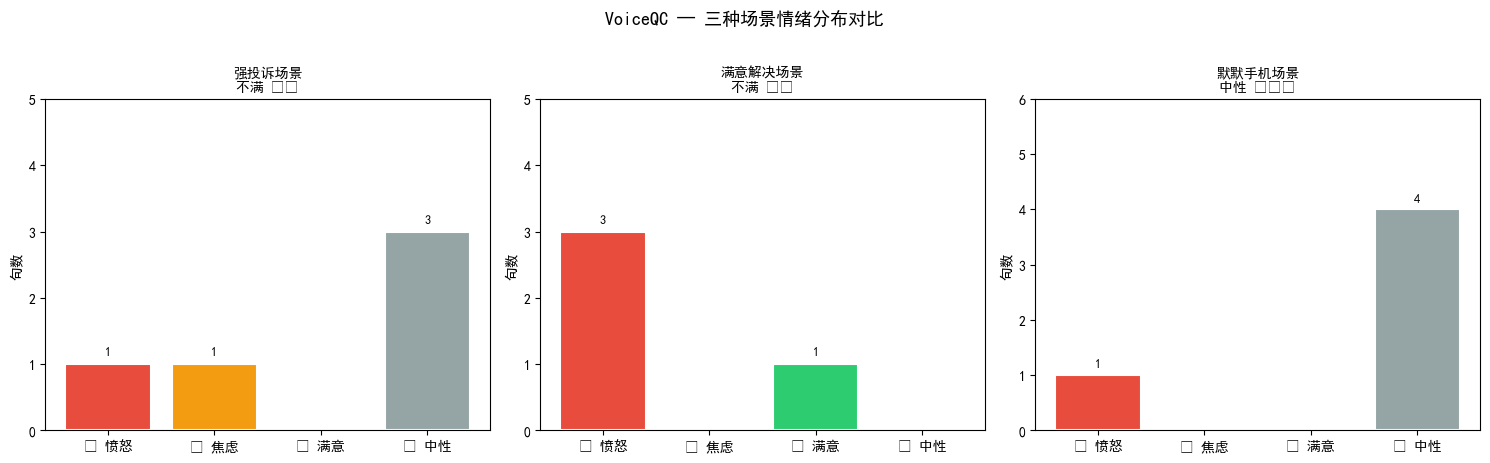

Saved: emotion_comparison.png


In [38]:
# 情绪分布对比图
labels   = ['😠 愤怒', '😰 焦虑', '😊 满意', '😐 中性']
colors   = ['#e74c3c', '#f39c12', '#2ecc71', '#95a5a6']
names    = [sc['name'] for sc in SCENARIOS]
n        = len(reports)

fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.5))
if n == 1:
    axes = [axes]

for ax, report, name in zip(axes, reports, names):
    values = [
        report.angry_count,
        report.anxious_count,
        report.satisfied_count,
        report.neutral_count,
    ]
    bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(f'{name}\n{report.satisfaction_label}', fontsize=10, fontweight='bold')
    ax.set_ylabel('句数')
    ax.set_ylim(0, max(values) + 2 if max(values) > 0 else 3)
    for bar, val in zip(bars, values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    str(val), ha='center', va='bottom', fontsize=9)

plt.suptitle('VoiceQC — 三种场景情绪分布对比', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
chart_path = out_dir / 'emotion_comparison.png'
fig.savefig(str(chart_path), bbox_inches='tight', dpi=130)
plt.show()
print(f'Saved: {chart_path.name}')

## 7 Gradio 一键演示

支持上传客服录音 / 麦克风录音 / 直接输入文本，展示：

- ASR 转录原文
- 逐句情绪标注
- 情绪统计摘要
- 完整 Markdown 质检报告 + 下载

In [ ]:
import importlib.util, sys
from pathlib import Path


_gh_path = Path(r'D:\zicheng_lee\modelscope-workshop\voiceqc\gradio_helper.py')
_spec    = importlib.util.spec_from_file_location('gradio_helper', _gh_path)
_mod     = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)

make_demo = _mod.make_demo

demo = make_demo(asr_model=asr_model)

try:
    demo.launch(debug=True)
except Exception:
    demo.launch(debug=True, share=True)